In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, delimiter=";")

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Define input (X) and output (y)
X = data.iloc[:, :-1].values  # Features (all except last column)
y = data.iloc[:, -1].values   # Target (wine quality score)

# One-hot encode target variable
ohe = OneHotEncoder(sparse_output=False)  # Use sparse_output instead of sparse
y = ohe.fit_transform(y.reshape(-1, 1))


# Split data into training + validation sets (80%) and test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split the training + validation set into separate training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
# Define network architecture
input_size = X_train.shape[1]  # Number of features (11)
hidden_size1 = 16
hidden_size2 = 32  # Adding second hidden layer
output_size = y_train.shape[1]  # Number of classes

In [ ]:
# Initialize weights and biases
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size1) * np.sqrt(1 / input_size)
b1 = np.zeros((1, hidden_size1))
W2 = np.random.randn(hidden_size1, hidden_size2) * np.sqrt(1 / hidden_size1)
b2 = np.zeros((1, hidden_size2))
W3 = np.random.randn(hidden_size2, output_size) * np.sqrt(1 / hidden_size2)
b3 = np.zeros((1, output_size))


In [ ]:
# Activation functions
def relu(Z):
    return np.maximum(0, Z)

def leaky_relu(Z, alpha=0.01):
    return np.where(Z > 0, Z, alpha * Z)

In [ ]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

In [ ]:
# Forward propagation
def forward_propagation(X):
    Z1 = np.dot(X, W1) + b1
    A1 = leaky_relu(Z1)  # Leaky ReLU

    Z2 = np.dot(A1, W2) + b2
    A2 = leaky_relu(Z2)

    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [ ]:
# Compute loss (categorical cross-entropy)
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    return loss

In [ ]:
# Compute accuracy
def compute_accuracy(y_true, y_pred):
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)
    return np.mean(y_true_labels == y_pred_labels)

In [ ]:
# Backpropagation
def backward_propagation(X, y, Z1, A1, Z2, A2, Z3, A3):
    m = X.shape[0]

    dZ3 = A3 - y
    dW3 = np.dot(A2.T, dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * (Z2 > 0)  # Derivative of Leaky ReLU
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)  # Derivative of Leaky ReLU
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [ ]:
# Training with Early Stopping and Tracking
epochs = 1000
learning_rate = 0.01
patience = 100  # Early stopping patience (epochs)
best_val_loss = float("inf")
no_improve_count = 0

# Track losses and accuracies
loss_history = []
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

In [ ]:
for epoch in range(epochs):
    # Forward pass
    Z1, A1, Z2, A2, Z3, A3 = forward_propagation(X_train)
    Z1_val, A1_val, Z2_val, A2_val, Z3_val, A3_val = forward_propagation(X_val)

    # Compute loss
    train_loss = compute_loss(y_train, A3)
    val_loss = compute_loss(y_val, A3_val)
    loss_history.append(train_loss)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # Compute training and validation accuracy
    train_acc = compute_accuracy(y_train, A3)
    val_acc = compute_accuracy(y_val, A3_val)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    # Backward pass
    dW1, db1, dW2, db2, dW3, db3 = backward_propagation(X_train, y_train, Z1, A1, Z2, A2, Z3, A3)

    # Update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    # Early stopping: Check if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_count = 0  # Reset counter if improvement
    else:
        no_improve_count += 1

    if no_improve_count >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

    # Print logs every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 0, Train Loss: 1.8171, Train Acc: 0.1652, Val Loss: 1.8484, Val Acc: 0.1797
Epoch 100, Train Loss: 1.3630, Train Acc: 0.5239, Val Loss: 1.4061, Val Acc: 0.5430
Epoch 200, Train Loss: 1.1960, Train Acc: 0.5630, Val Loss: 1.2418, Val Acc: 0.5234
Epoch 300, Train Loss: 1.1186, Train Acc: 0.5709, Val Loss: 1.1654, Val Acc: 0.5352
Epoch 400, Train Loss: 1.0752, Train Acc: 0.5728, Val Loss: 1.1226, Val Acc: 0.5469
Epoch 500, Train Loss: 1.0480, Train Acc: 0.5816, Val Loss: 1.0974, Val Acc: 0.5547
Epoch 600, Train Loss: 1.0293, Train Acc: 0.5826, Val Loss: 1.0822, Val Acc: 0.5508
Epoch 700, Train Loss: 1.0157, Train Acc: 0.5885, Val Loss: 1.0725, Val Acc: 0.5547
Epoch 800, Train Loss: 1.0048, Train Acc: 0.5924, Val Loss: 1.0654, Val Acc: 0.5508
Epoch 900, Train Loss: 0.9951, Train Acc: 0.5953, Val Loss: 1.0597, Val Acc: 0.5469



Final Training Accuracy: 59.82%
Final Validation Accuracy: 54.69%
Final Test Accuracy: 61.88%


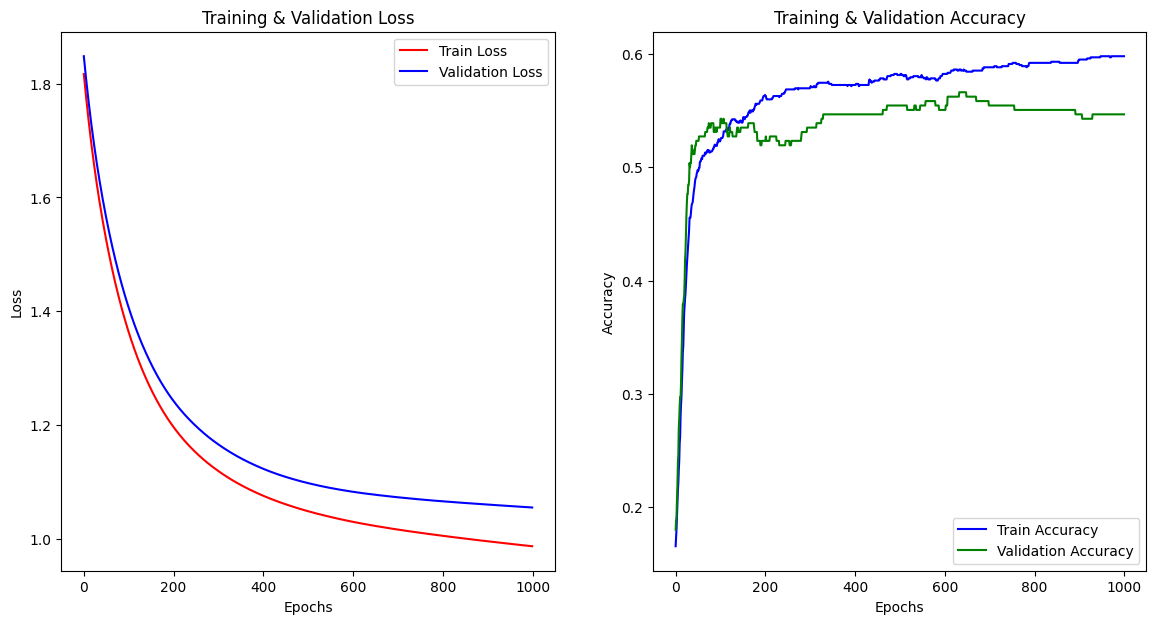

In [ ]:
# Final Accuracy
final_train_acc = compute_accuracy(y_train, forward_propagation(X_train)[-1])
final_val_acc = compute_accuracy(y_val, forward_propagation(X_val)[-1])
final_test_acc = compute_accuracy(y_test, forward_propagation(X_test)[-1])

print(f"\nFinal Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
print(f"Final Test Accuracy: {final_test_acc * 100:.2f}%")

# Plot loss and accuracy
plt.figure(figsize=(14, 7))

# Training and validation loss plot
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss", color='red')
plt.plot(val_loss_history, label="Validation Loss", color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# Training and validation accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label="Train Accuracy", color='blue')
plt.plot(val_acc_history, label="Validation Accuracy", color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
# Perform forward propagation on test set
_, _, _, _, _, A3_test = forward_propagation(X_test)

# Convert predictions to class labels
y_test_pred = np.argmax(A3_test, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Compute test accuracy
test_accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

# Display classification report
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred))



Final Test Accuracy: 61.88%

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        11
           2       0.68      0.79      0.73       136
           3       0.57      0.65      0.61       128
           4       0.47      0.20      0.28        40
           5       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.29      0.27      0.27       320
weighted avg       0.58      0.62      0.59       320



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
